#### Comparing the models based on the SVG test

- SVG stands for Scalable Vector Graphics

- It is an XML based image format used to display two-dimensional graphics

- Unlike JPEG or PNG files that use pixels, SVG images use math and geometry to draw shapes, lines and curves

In [ ]:
import os
from dotenv import load_dotenv
from openai import OpenAI
from datetime import datetime
import time
from IPython.display import Markdown, display, SVG      # built in SVG image using IPython's built-in SVG display

try:
    from revealer import reveal                         # try importing the reveal module
except ModuleNotFoundError:
    def reveal(svg_text):                               # if there is an error in importing the module reveal, there will be a custom function reveal 
        display(SVG(data=svg_text))                     # custom function reveal to display the SVG image using IPython's built-in SVG display

In [8]:
load_dotenv(override=True)

openrouter_base_url = os.getenv('OPENROUTER_BASE_URL')
openrouter_api_key = os.getenv('OPENROUTER_API_KEY')

openrouter = OpenAI(base_url = openrouter_base_url, api_key = openrouter_api_key)

if openrouter_api_key:
    print(f'OpenRouter API Key found and starts with {openrouter_api_key[0:3]}')
else:
    print('OpenRouter API Key not found')

OpenRouter API Key found and starts with sk-


In [9]:
challenge = "a panda rollerblading to work"
prompt = f"Generate an SVG of {challenge}. Respond with SVG only, no code blocks"
messages = [{'role':'user', 'content':prompt}]

In [ ]:
def artist(model, effort=None):
    try:
        start = datetime.now()
        response = openrouter.chat.completions.create(
            model = model,
            messages = messages,
            reasoning_effort = effort
        )
        result = response.choices[0].message.content
        end = datetime.now()
        elapsed = (end-start).total_seconds()       # convert the difference into seconds
        heading = f"###{model}\n**Time:** {elapsed // 60:.0f} min {elapsed % 60:.0f} s\n\n"     # convert the runtime from seconds into minutes and seconds
    except Exception as e:
        print(f"Model {model} failed: {e}")
        heading = f'### {model}\n**Error:** {e}\n\n'
        return heading, None
    return heading, result              # returns the model details as first part and then the SVG image as the second part

In [13]:
results = [
    artist("openai/gpt-oss-120b"),
    artist("openai/gpt-5-nano", effort="low"),
    artist("deepseek/deepseek-v3.2"),
    artist("moonshotai/kimi-k2-thinking"),
    artist("x-ai/grok-4.3"),
    artist("anthropic/claude-opus-4.5"),
    artist("openai/gpt-5.2", effort="high"),
    artist("google/gemini-3.6-flash")
]

Model moonshotai/kimi-k2-thinking failed: Error code: 402 - {'error': {'message': 'This request requires more credits, or fewer max_tokens. You requested up to 65536 tokens, but can only afford 15862. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account', 'code': 402, 'metadata': {'limit_source': 'openrouter_credits', 'remedy_hint': 'Add credits at https://openrouter.ai/settings/credits, or lower max_tokens / prompt size to fit your remaining balance.', 'provider_name': None, 'previous_errors': [{'code': 402, 'message': 'This request requires more credits, or fewer max_tokens. You requested up to 65536 tokens, but can only afford 15862. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account'}]}}, 'user_id': 'user_3GrVekHkXwlCp7jPFQR9Iu9x8QT'}
Model x-ai/grok-4.3 failed: Error code: 402 - {'error': {'message': 'This request requires more credits, or fewer max_tokens. You requested up to 65536 tokens, but can only afford

###openai/gpt-oss-120b
**Time:** 1 min 12 s



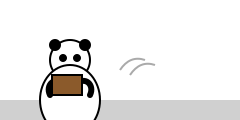

###openai/gpt-5-nano
**Time:** 0 min 17 s



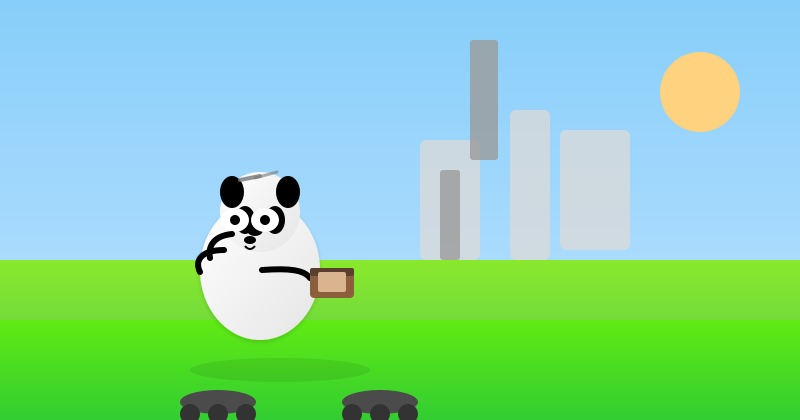

###deepseek/deepseek-v3.2
**Time:** 0 min 7 s



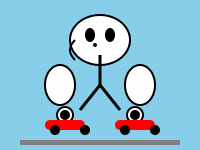

### moonshotai/kimi-k2-thinking
**Error:** Error code: 402 - {'error': {'message': 'This request requires more credits, or fewer max_tokens. You requested up to 65536 tokens, but can only afford 15862. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account', 'code': 402, 'metadata': {'limit_source': 'openrouter_credits', 'remedy_hint': 'Add credits at https://openrouter.ai/settings/credits, or lower max_tokens / prompt size to fit your remaining balance.', 'provider_name': None, 'previous_errors': [{'code': 402, 'message': 'This request requires more credits, or fewer max_tokens. You requested up to 65536 tokens, but can only afford 15862. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account'}]}}, 'user_id': 'user_3GrVekHkXwlCp7jPFQR9Iu9x8QT'}



<IPython.core.display.SVG object>

### x-ai/grok-4.3
**Error:** Error code: 402 - {'error': {'message': 'This request requires more credits, or fewer max_tokens. You requested up to 65536 tokens, but can only afford 15862. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account', 'code': 402, 'metadata': {'limit_source': 'openrouter_credits', 'remedy_hint': 'Add credits at https://openrouter.ai/settings/credits, or lower max_tokens / prompt size to fit your remaining balance.', 'provider_name': None, 'previous_errors': [{'code': 402, 'message': 'This request requires more credits, or fewer max_tokens. You requested up to 65536 tokens, but can only afford 15862. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account'}]}}, 'user_id': 'user_3GrVekHkXwlCp7jPFQR9Iu9x8QT'}



<IPython.core.display.SVG object>

### anthropic/claude-opus-4.5
**Error:** Error code: 402 - {'error': {'message': 'This request requires more credits, or fewer max_tokens. You requested up to 64000 tokens, but can only afford 1586. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account', 'code': 402, 'metadata': {'limit_source': 'openrouter_credits', 'remedy_hint': 'Add credits at https://openrouter.ai/settings/credits, or lower max_tokens / prompt size to fit your remaining balance.', 'provider_name': None, 'previous_errors': [{'code': 402, 'message': 'This request requires more credits, or fewer max_tokens. You requested up to 64000 tokens, but can only afford 1586. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account'}, {'code': 402, 'message': 'This request requires more credits, or fewer max_tokens. You requested up to 64000 tokens, but can only afford 1586. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account'}, {'code': 402, 'message': 'This request requires more credits, or fewer max_tokens. You requested up to 64000 tokens, but can only afford 1586. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account'}, {'code': 402, 'message': 'This request requires more credits, or fewer max_tokens. You requested up to 64000 tokens, but can only afford 1586. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account'}]}}, 'user_id': 'user_3GrVekHkXwlCp7jPFQR9Iu9x8QT'}



<IPython.core.display.SVG object>

### openai/gpt-5.2
**Error:** Error code: 402 - {'error': {'message': 'This request requires more credits, or fewer max_tokens. You requested up to 65536 tokens, but can only afford 2832. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account', 'code': 402, 'metadata': {'limit_source': 'openrouter_credits', 'remedy_hint': 'Add credits at https://openrouter.ai/settings/credits, or lower max_tokens / prompt size to fit your remaining balance.', 'provider_name': None, 'previous_errors': [{'code': 402, 'message': 'This request requires more credits, or fewer max_tokens. You requested up to 65536 tokens, but can only afford 2832. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account'}]}}, 'user_id': 'user_3GrVekHkXwlCp7jPFQR9Iu9x8QT'}



<IPython.core.display.SVG object>

### google/gemini-3.6-flash
**Error:** Error code: 402 - {'error': {'message': 'This request requires more credits, or fewer max_tokens. You requested up to 65536 tokens, but can only afford 5287. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account', 'code': 402, 'metadata': {'limit_source': 'openrouter_credits', 'remedy_hint': 'Add credits at https://openrouter.ai/settings/credits, or lower max_tokens / prompt size to fit your remaining balance.', 'provider_name': None, 'previous_errors': [{'code': 402, 'message': 'This request requires more credits, or fewer max_tokens. You requested up to 65536 tokens, but can only afford 5287. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account'}]}}, 'user_id': 'user_3GrVekHkXwlCp7jPFQR9Iu9x8QT'}



<IPython.core.display.SVG object>

In [ ]:
for result in results:
    try:
        display(Markdown(result[0]))            # model details as the first part along with the Markdown
        reveal(result[1])                       # SVG image as the second part of the result
        time.sleep(12)
    except Exception as e:
        print(f'Error displaying result: {e}')